20.602041703090325
20.684
A formulação explícita não satisfaz a condição de estabilidade.
lambda = 0.6189226970203435


C:\Users\brend\OneDrive\Documentos\Faculdade\SimRes\src\erros.py:30: RuntimeWarning: overflow encountered in square
  np.sum((P_ref - P_num)**2)
C:\Users\brend\OneDrive\Documentos\Faculdade\SimRes\src\erros.py:48: RuntimeWarning: overflow encountered in square
  (P_ref - P_num)**2



Erros para Nx = 100 e Nt = 1200
L1 = 8.595564238156807e+206
L1 relativo = 4.155756702587204e+199
L2 = inf
L2 relativo = inf
MSE = inf
RMSE = inf
Linf = 4.60634899220791e+206


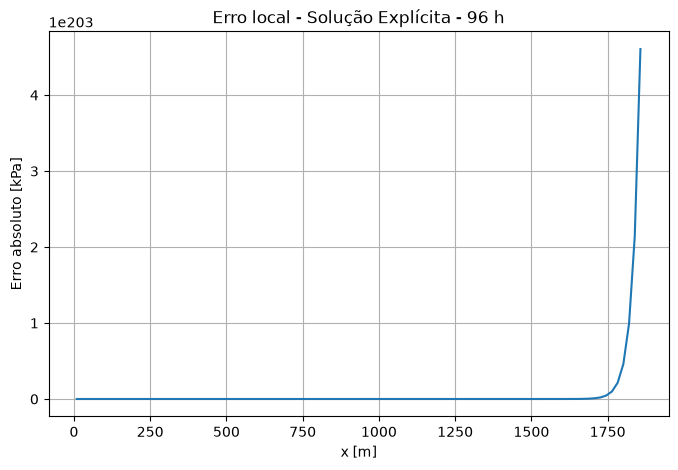

A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.


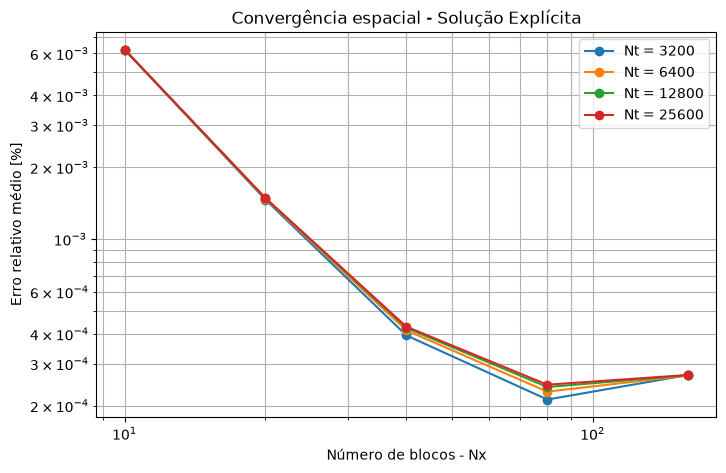

A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.


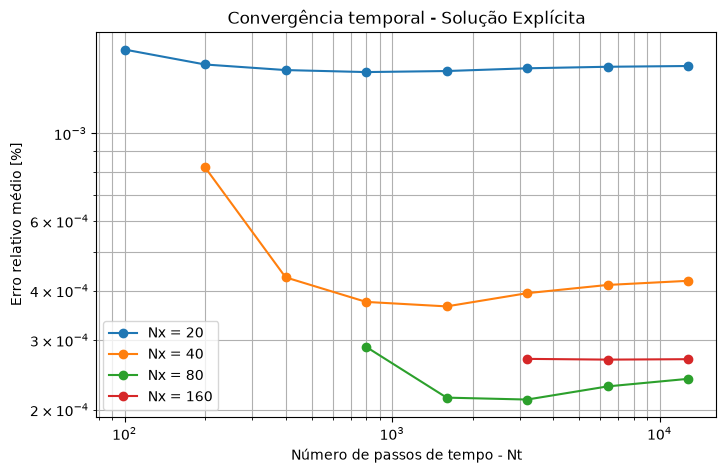

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from analytical.transiente_L1d_FP import linear_trans_1d_FP
from mdf.explicita import explicita_1d_FP

from erros import (
    erro_local,
    erro_L1,
    erro_L1_relativo,
    erro_L2,
    erro_L2_relativo,
    erro_MSE,
    erro_RMSE,
    erro_Linf
)


# ==========================================================
# parâmetros
# ==========================================================

p0 = 20.684e6
Pe = p0

A_R = 3484800
L = np.sqrt(A_R)

qw = 4.968e-3

k = 339 * 9.869233e-16
phi = 0.22
ct = 3.046e-9
mu = 1.0e-3

h = 4.572
largura = L
A = h * largura

t_h = 96
t_final = t_h * 3600

eta = k / (phi * ct * mu)


# ==========================================================
# solução analítica
# ==========================================================

x_an, t_an, X, T, P_an = linear_trans_1d_FP(
    p0,
    qw,
    L,
    k,
    A,
    mu,
    eta,
    t_final
)


# ==========================================================
# solução explícita - caso base
# ==========================================================

nx = 100
nt = 800

x_exp, t_exp, P_exp, lambd = explicita_1d_FP(
    p0,
    Pe,
    -qw,
    h,
    L,
    largura,
    k,
    phi,
    ct,
    mu,
    t_final,
    nx,
    nt
)

print("lambda =", lambd)


# ==========================================================
# erros do caso base
# ==========================================================

# solução analítica nos pontos da malha numérica

P_ref = np.interp(
    x_exp,
    x_an,
    P_an[-1, :]
)

P_num = P_exp[-1, :]


# erros

local = erro_local(P_ref, P_num)

L1 = erro_L1(P_ref, P_num)
L1_rel = erro_L1_relativo(P_ref, P_num)

L2 = erro_L2(P_ref, P_num)
L2_rel = erro_L2_relativo(P_ref, P_num)

MSE = erro_MSE(P_ref, P_num)
RMSE = erro_RMSE(P_ref, P_num)

Linf = erro_Linf(P_ref, P_num)


print("\nErros para Nx = 100 e Nt = 1200")

print("L1 =", L1)
print("L1 relativo =", L1_rel)

print("L2 =", L2)
print("L2 relativo =", L2_rel)

print("MSE =", MSE)
print("RMSE =", RMSE)

print("Linf =", Linf)


# ==========================================================
# erro local
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    x_exp,
    local / 1e3
)

plt.xlabel("x [m]")
plt.ylabel("Erro absoluto [kPa]")
plt.title("Erro local - Solução Explícita - 96 h")

plt.grid()
plt.show()


# ==========================================================
# refinamento espacial
#
# varia Nx:
# quanto maior Nx, maior o refinamento espacial
#
# cada curva corresponde a um Nt diferente
# ==========================================================

nx_values = [
    10,
    20,
    40,
    80,
    160
]

nt_values_espacial = [
    3200,
    6400,
    12800,
    25600
]


plt.figure(figsize=(8, 5))


for nt_i in nt_values_espacial:

    erros_espaciais = []

    for nx_i in nx_values:

        x_i, t_i, P_i, lambd_i = explicita_1d_FP(
            p0,
            Pe,
            -qw,
            h,
            L,
            largura,
            k,
            phi,
            ct,
            mu,
            t_final,
            nx_i,
            nt_i
        )

        # solução analítica na malha numérica

        P_ref_i = np.interp(
            x_i,
            x_an,
            P_an[-1, :]
        )

        # erro relativo percentual médio

        erro_i = (
            erro_L1_relativo(
                P_ref_i,
                P_i[-1, :]
            )
            / nx_i
        ) * 100

        erros_espaciais.append(
            erro_i
        )


    plt.loglog(
        nx_values,
        erros_espaciais,
        "o-",
        label=f"Nt = {nt_i}"
    )


plt.xlabel("Número de blocos - Nx")
plt.ylabel("Erro relativo médio [%]")
plt.title("Convergência espacial - Solução Explícita")

plt.legend()
plt.grid(True, which="both")
plt.show()


# ==========================================================
# refinamento temporal
#
# varia Nt:
# quanto maior Nt, menor o passo de tempo
#
# cada curva corresponde a um Nx diferente
# ==========================================================

nx_values_temporal = [
    20,
    40,
    80,
    160
]

nt_values = [
    100,
    200,
    400,
    800,
    1600,
    3200,
    6400,
    12800
]


plt.figure(figsize=(8, 5))


for nx_i in nx_values_temporal:

    nt_estaveis = []
    erros_temporais = []

    dx_i = L / nx_i


    for nt_i in nt_values:

        dt_i = t_final / nt_i

        lambd_i = eta * dt_i / dx_i**2


        # ignora combinações que não satisfazem
        # a estabilidade da formulação explícita

        if lambd_i > 0.5:
            continue


        x_i, t_i, P_i, lambd_i = explicita_1d_FP(
            p0,
            Pe,
            -qw,
            h,
            L,
            largura,
            k,
            phi,
            ct,
            mu,
            t_final,
            nx_i,
            nt_i
        )


        # solução analítica na malha numérica

        P_ref_i = np.interp(
            x_i,
            x_an,
            P_an[-1, :]
        )


        # erro relativo percentual médio

        erro_i = (
            erro_L1_relativo(
                P_ref_i,
                P_i[-1, :]
            )
            / nx_i
        ) * 100


        nt_estaveis.append(
            nt_i
        )

        erros_temporais.append(
            erro_i
        )


    plt.loglog(
        nt_estaveis,
        erros_temporais,
        "o-",
        label=f"Nx = {nx_i}"
    )


plt.xlabel("Número de passos de tempo - Nt")
plt.ylabel("Erro relativo médio [%]")
plt.title("Convergência temporal - Solução Explícita")

plt.legend()
plt.grid(True, which="both")
plt.show()